# Seaborn - Matrix Plots

Los objetivos de aprendizaje son:

1. Matrix Plots
    - Datos
    - Cramer's V
    - heatmap
    - clustermap

## Datos

Para esta sección utilizaremos los DataFrames:

* `tips`
* `flights`

el DataFrame `flights` contiene información acerca de el número de pasajeros promedio en los vuelos de EEUU por año y mes. La información ha sido recabada entre los años 1949 y 1960.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(10, 6)})

tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')
flights.head(3)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132


## Cramer's V

Para medir el grado de asociación de de las variable categóricas podemos usar [Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V).

Se trata de un valor continuo ente $[0,1]$, en donde un valor de 0 implica que la distribución de valores de la tabla cruzada es perfectamente uniforme.

In [2]:
def cramers_v(x,y):
    from scipy.stats import chi2_contingency
    from pandas import crosstab
    from numpy import sqrt

    data = crosstab(x,y)
    
    chi2 = chi2_contingency(data, correction = False)[0]

    n = data.sum().sum()
    mindim = min(data.shape)-1
    v = sqrt((chi2/n)/mindim)
    
    return v

In [3]:
def cramers_corr(df):
    from pandas import DataFrame
    from numpy import zeros
    
    columnas_cat = df.select_dtypes(include=['category', 'O']).columns
    
    matriz_cramer = DataFrame(
        data = zeros((len(columnas_cat),len(columnas_cat))),
        columns = columnas_cat,
        index = columnas_cat)
    
    n = len(columnas_cat)
    
    for i in range(0,n):
        x = columnas_cat[i]
        for j in range(i,n):
            y = columnas_cat[j]
            if x == y:
                matriz_cramer[x][y] = 1
            else:
                value = cramers_v(df[x],df[y])
                matriz_cramer[x][y] = value
                matriz_cramer[y][x] = value
    
    return matriz_cramer

Vamos a aplicar lo anterior para ver el grado de asociación entre las columnas categóricas de nuestro DataFrame `tips`  

In [4]:
cramers_corr(tips)

C:\Users\lucai\AppData\Local\Temp\ipykernel_7960\1801502141.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  matriz_cramer[x][y] = 1
C:\Users\lucai\AppData\Local\Temp\ipykernel_7960\1801502141.py:22: FutureWarning: ChainedAssignmentError

,sex,smoker,day,time
sex,1.000000,0.002816,0.232784,0.205231
smoker,0.002816,1.000000,0.325093,0.054921
day,0.232784,0.325093,1.000000,0.943295
time,0.205231,0.054921,0.943295,1.000000


¿Qué significa que `day` y `time` tengan un valor muy cercano a 1? veamos la tabla con el número de observaciones agrupado por el producto cruzado de los valores de ambas variables.

In [5]:
print("Ejemplo de valores muy cercanos a 1")
display(pd.crosstab(tips['day'],tips['time']))
print("Ejemplo de valores muy cercanos a 0")
display(pd.crosstab(tips['smoker'],tips['sex']))

Ejemplo de valores muy cercanos a 1


time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


Ejemplo de valores muy cercanos a 0


sex,Male,Female
smoker,,
Yes,60,33
No,97,54


## `sns.heatmap`

La función [`sns.heatmap()`](https://seaborn.pydata.org/generated/seaborn.heatmap.html) genera un gráfico en formato rectangular y codificado con colores.

### Correlación Lineal

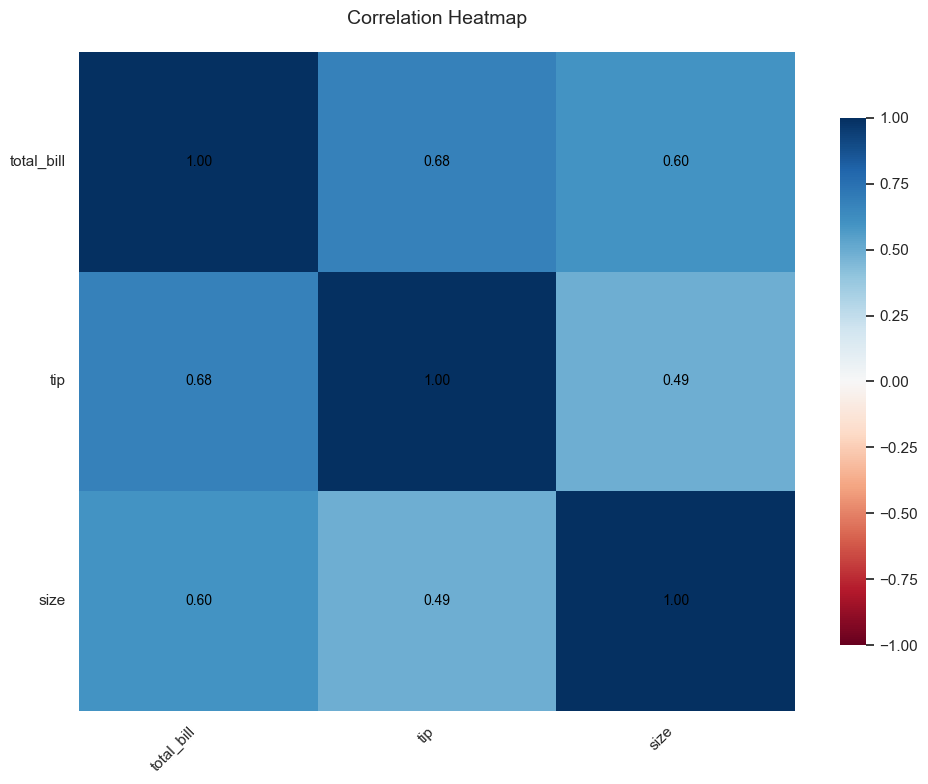

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")
corr = tips.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap="RdBu",
    cbar_kws={"shrink": 0.8},
    annot=False,  # turn Seaborn's buggy annotation off
)

# ✅ Manually add text annotations
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Correlation Heatmap", fontsize=14, pad=20)

plt.tight_layout()
plt.show()


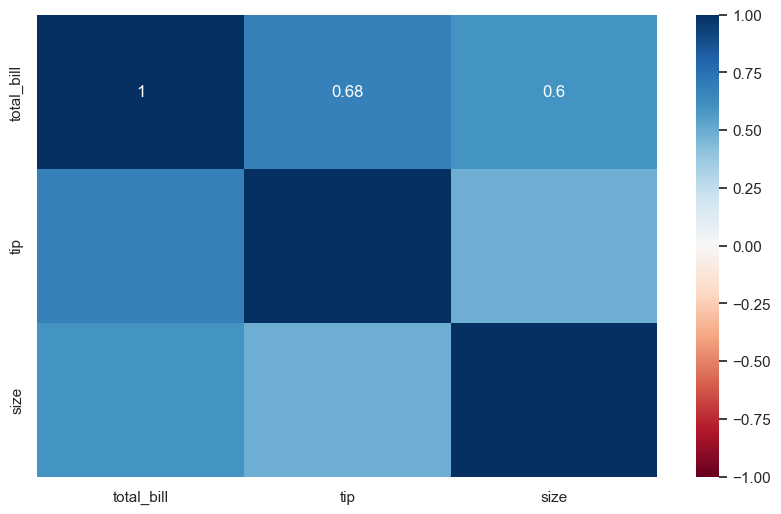

In [7]:
ax = sns.heatmap(
    tips.corr(numeric_only=True),
    vmin = -1, vmax = 1, center=0, annot=True, cmap = "RdBu") 

### Matriz con los Valores de Cramer

C:\Users\lucai\AppData\Local\Temp\ipykernel_7960\1801502141.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  matriz_cramer[x][y] = 1
C:\Users\lucai\AppData\Local\Temp\ipykernel_7960\1801502141.py:22: FutureWarning: ChainedAssignmentError

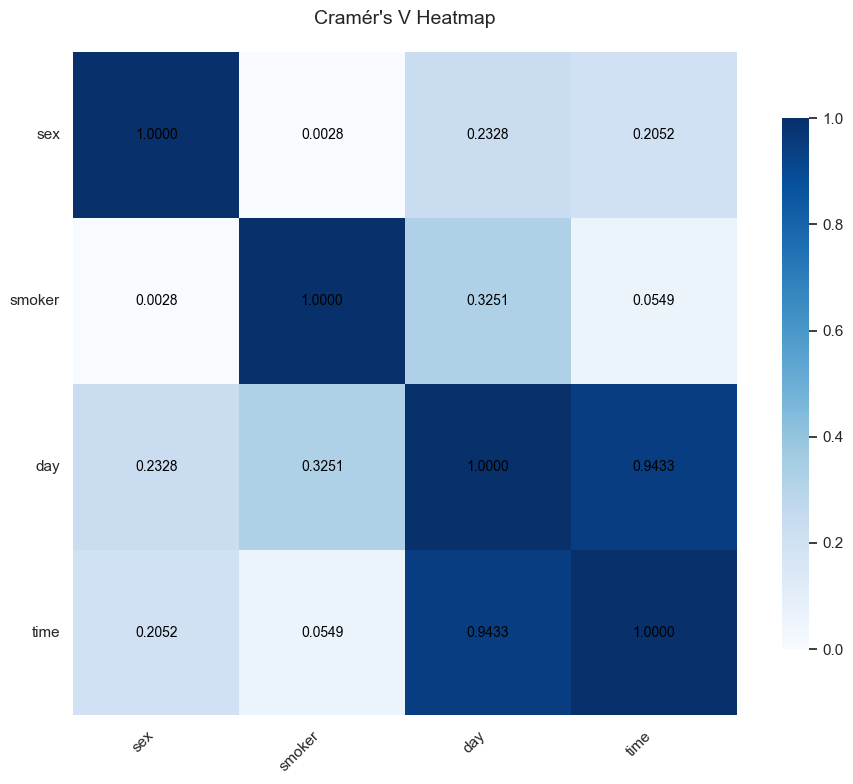

In [8]:

# Compute Cramér's V
cramers_matrix = cramers_corr(tips)

# Create figure
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cramers_matrix,
    vmin=0, vmax=1, center=0.5,
    cmap="Blues",
    annot=False,  # turn off Seaborn's buggy annot
    square=True,
    cbar_kws={"shrink": 0.8}
)

# Manually add annotation for every cell
for i in range(cramers_matrix.shape[0]):
    for j in range(cramers_matrix.shape[1]):
        value = cramers_matrix.iloc[i, j]
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.4f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

# Rotate labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Cramér's V Heatmap", fontsize=14, pad=20)

plt.tight_layout()
plt.show()

### Ejemplo con la tabla pivote 

C:\Users\lucai\AppData\Local\Temp\ipykernel_7960\2225287387.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_flights = flights.pivot_table(values='passengers',index='month',columns='year')


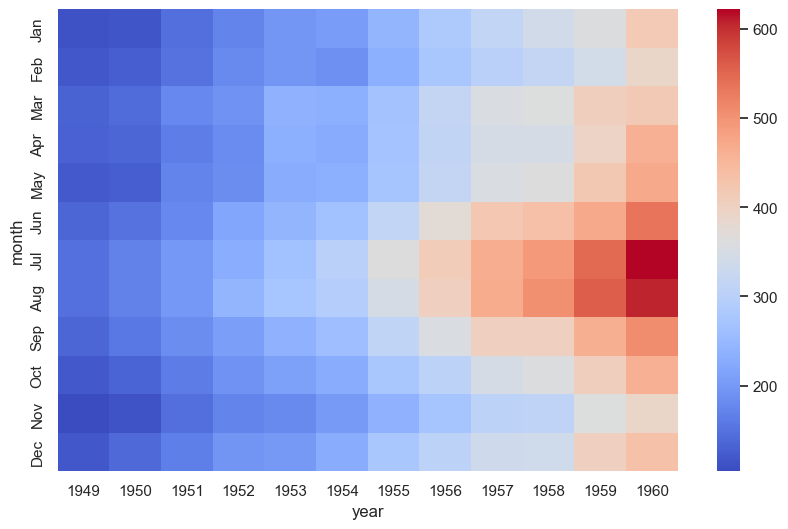

In [9]:
pivot_flights = flights.pivot_table(values='passengers',index='month',columns='year')
ax = sns.heatmap(pivot_flights, cmap = "coolwarm")

## `sns.clustermap`

La función [`sns.clustermap()`](https://seaborn.pydata.org/generated/seaborn.clustermap.html) genera un heatmap ordenando las columnas y renglones de la matriz mediante un clúster jerárquico.

Veamos cómo funciona.


AttributeError: module 'numpy' has no attribute 'product'

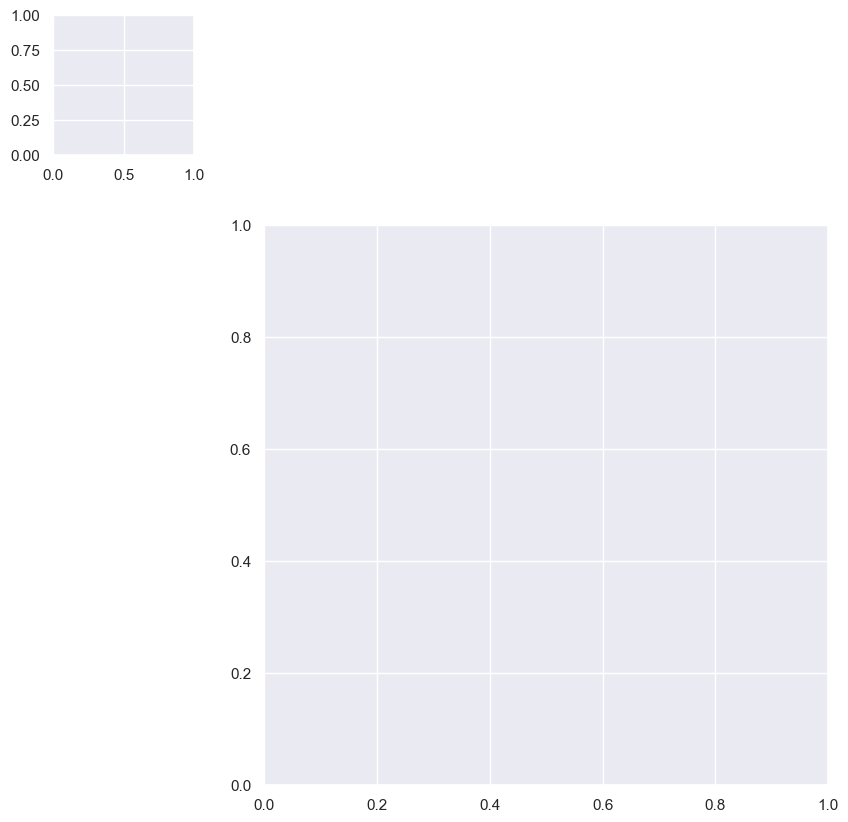

In [10]:
ax = sns.clustermap(pivot_flights, cmap = "coolwarm",standard_scale=1)

In [12]:
import numpy
print(numpy.__version__)
print(numpy.__file__)

2.3.2
C:\Users\lucai\projects\curso-python-cac\.venv\Lib\site-packages\numpy\__init__.py
